# Data Loading and Exploratory Data Analysis

In [4]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)

# Plot Style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

# Load the Dataset

In [5]:
# Load Dataset
df = pd.read_csv(r"C:\Users\amans\Downloads\train.csv.zip")

# Display first five rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


# View Dataset

In [6]:
print("Dataset Shape :", df.shape)

df.info()

Dataset Shape : (9800, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-n

# Missing Values

In [7]:
missing = df.isnull().sum()
missing[missing>0]

Postal Code    11
dtype: int64

In [8]:
df.drop_duplicates(inplace=True)

print(df.shape)

(9800, 18)


In [9]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')


# Convert Date Columns

In [10]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

# Data Types

In [11]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

# Feature Engineering

In [44]:
df["Year"] = df["Order Date"].dt.year

In [13]:
df["Month"] = df["Order Date"].dt.month

In [14]:
df["Month Name"] = df["Order Date"].dt.month_name()

In [15]:
df["Week"] = df["Order Date"].dt.isocalendar().week

In [16]:
df["Day"] = df["Order Date"].dt.day

In [17]:
df["Day Name"] = df["Order Date"].dt.day_name()

In [18]:
df["Quarter"] = df["Order Date"].dt.quarter

In [19]:
def season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Summer"

    elif month in [6,7,8]:
        return "Monsoon"

    else:
        return "Autumn"

df["Season"] = df["Month"].apply(season)

In [20]:
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [21]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week,Day,Day Name,Quarter,Season,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,8,Wednesday,4,Autumn,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,8,Wednesday,4,Autumn,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,12,Monday,2,Monsoon,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,11,Tuesday,4,Autumn,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,11,Tuesday,4,Autumn,7


# Basic Statistics

In [22]:
df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week,Day,Day Name,Quarter,Season,Shipping Days
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000,9800.000000,9800.000000,9800,9800.0,9800.000000,9800,9800.000000,9800,9800.000000
unique,NaN,4922,NaN,NaN,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN,NaN,NaN,12,<NA>,NaN,7,NaN,4,NaN
top,NaN,CA-2018-100111,NaN,NaN,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,November,<NA>,NaN,Tuesday,NaN,Autumn,NaN
freq,NaN,14,NaN,NaN,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN,NaN,NaN,1449,<NA>,NaN,1889,NaN,3612,NaN
mean,4900.500000,NaN,2017-05-01 05:13:51.673469440,2017-05-05 04:17:52.653061120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059,2016.724184,7.818469,NaN,32.210102,15.486837,NaN,2.885816,NaN,3.961122
min,1.000000,NaN,2015-01-03 00:00:00,2015-01-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000,2015.000000,1.000000,NaN,1.0,1.000000,NaN,1.000000,NaN,0.000000
25%,2450.750000,NaN,2016-05-24 00:00:00,2016-05-27 18:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000,2016.000000,5.000000,NaN,21.0,8.000000,NaN,2.000000,NaN,3.000000
50%,4900.500000,NaN,2017-06-26 00:00:00,2017-06-29 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000,2017.000000,9.000000,NaN,35.0,16.000000,NaN,3.000000,NaN,4.000000
75%,7350.250000,NaN,2018-05-15 00:00:00,2018-05-19 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000,2018.000000,11.000000,NaN,45.0,23.000000,NaN,4.000000,NaN,5.000000
max,9800.000000,NaN,2018-12-30 00:00:00,2019-01-05 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99301.000000,NaN,NaN,NaN,NaN,NaN,22638.480000,2018.000000,12.000000,NaN,53.0,31.000000,NaN,4.000000,NaN,7.000000


# Histogram Plot

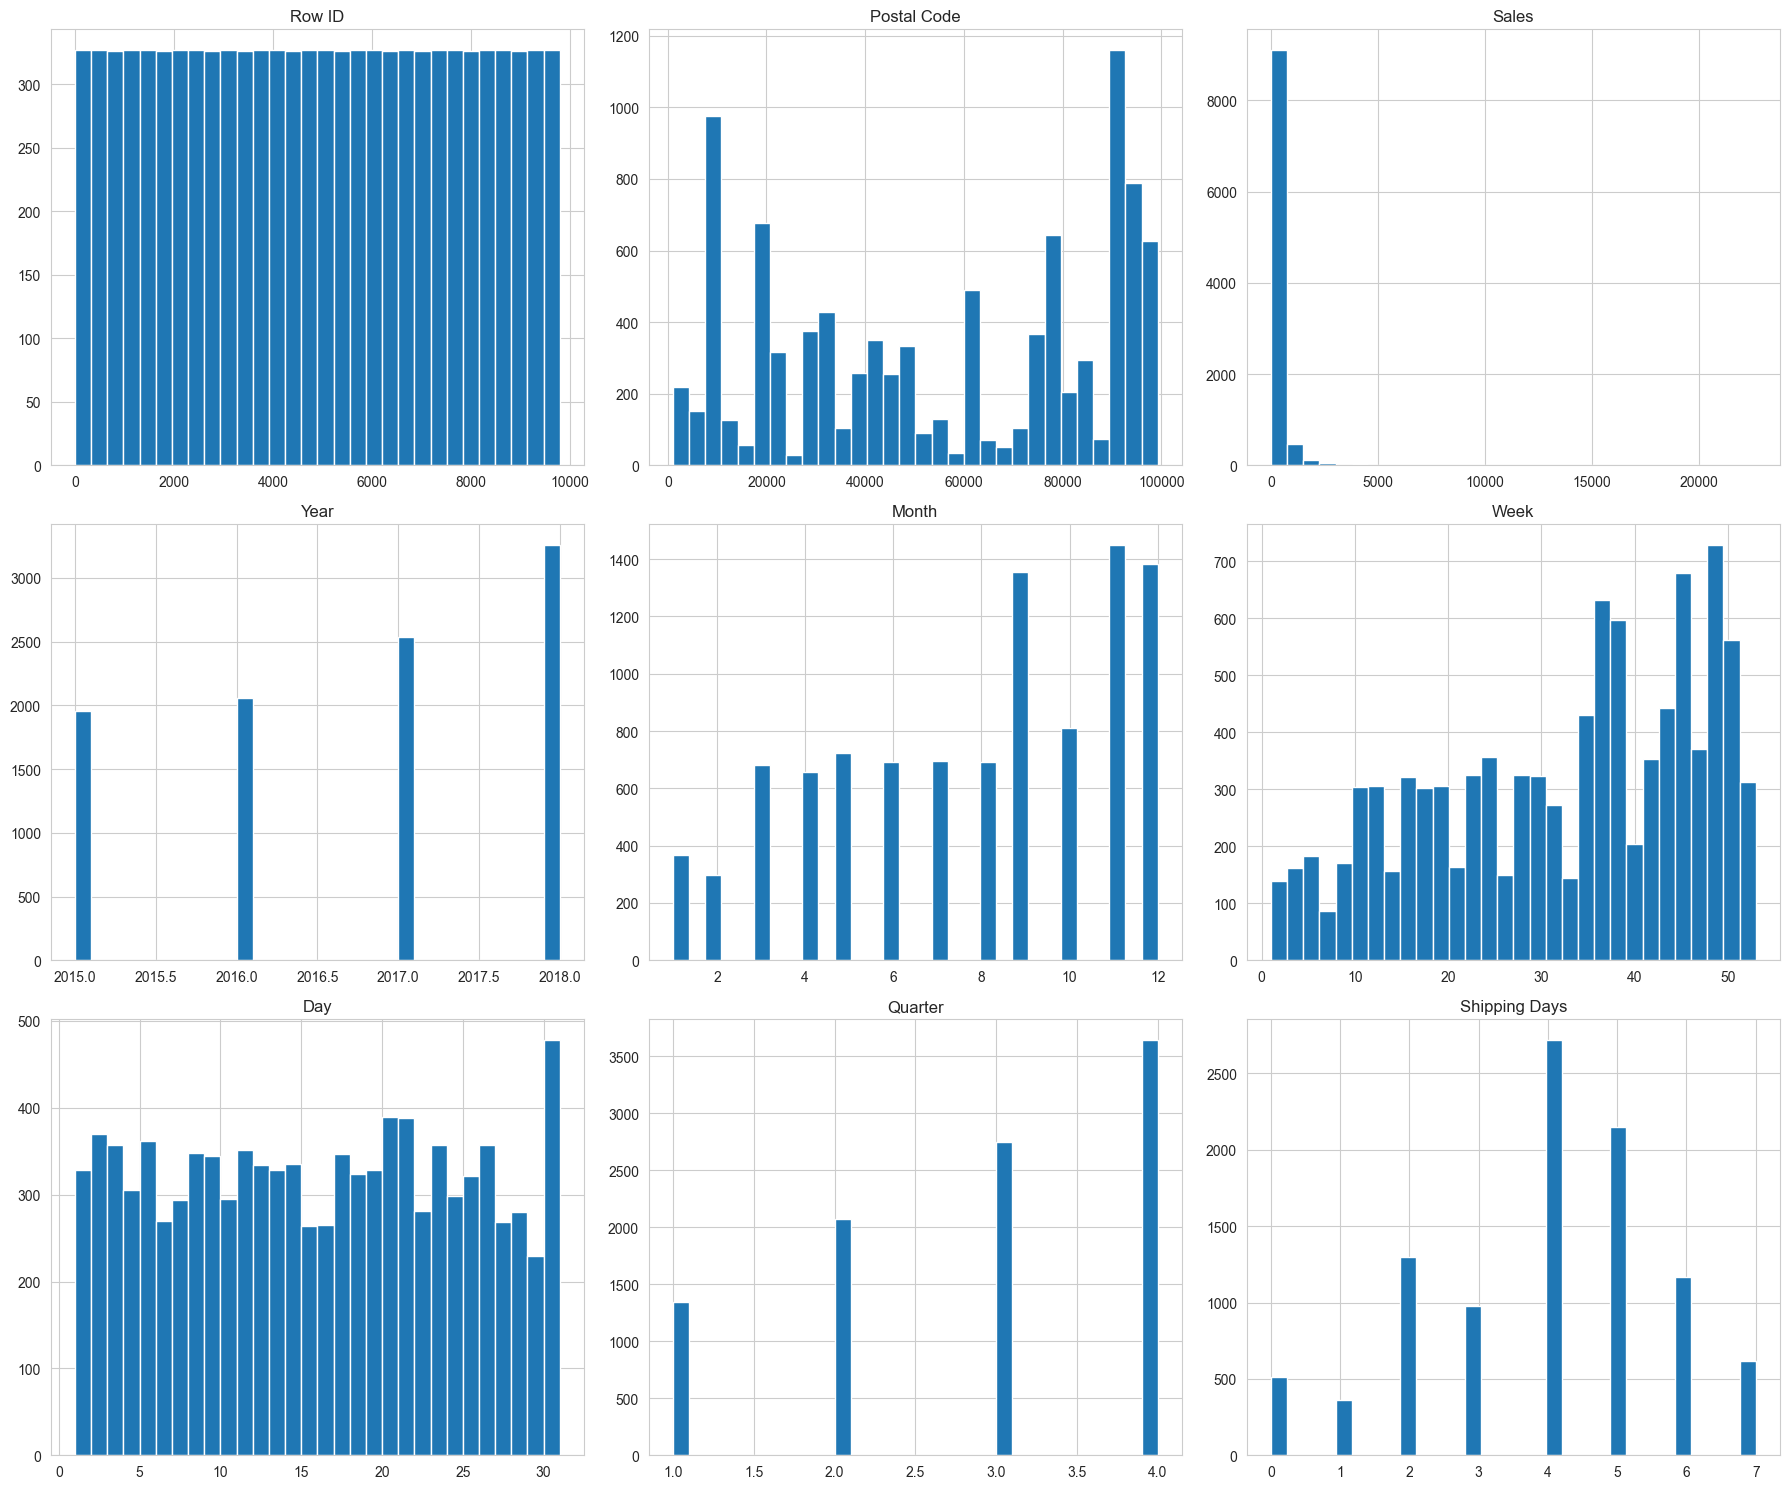

In [23]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(
    figsize=(18,15),
    bins=30
)

plt.tight_layout()

plt.show()

# Heatmap

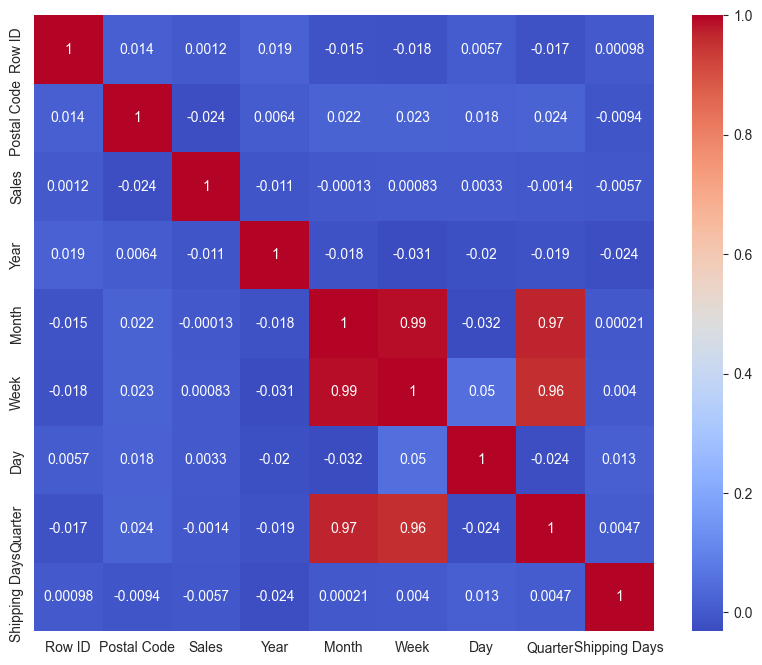

In [24]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

# Category Sales

In [25]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

# Total Sales By Category

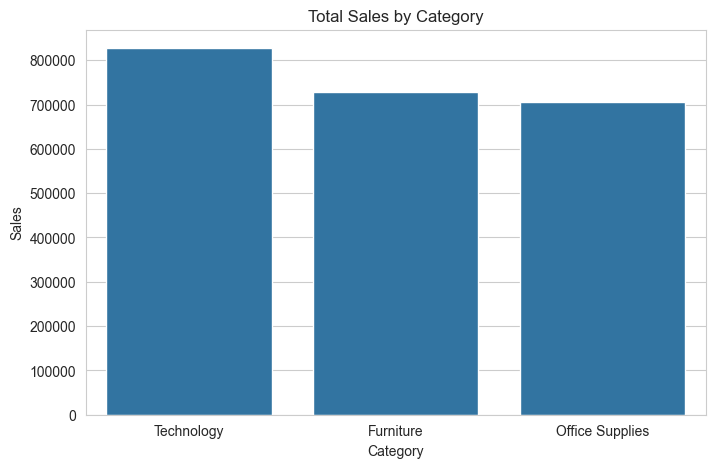

In [26]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Total Sales by Category")

plt.xlabel("Category")

plt.ylabel("Sales")

plt.show()

# Region Sales

In [27]:
region_sales = df.groupby("Region")["Sales"].sum()

region_sales

Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64

# Sales By Region

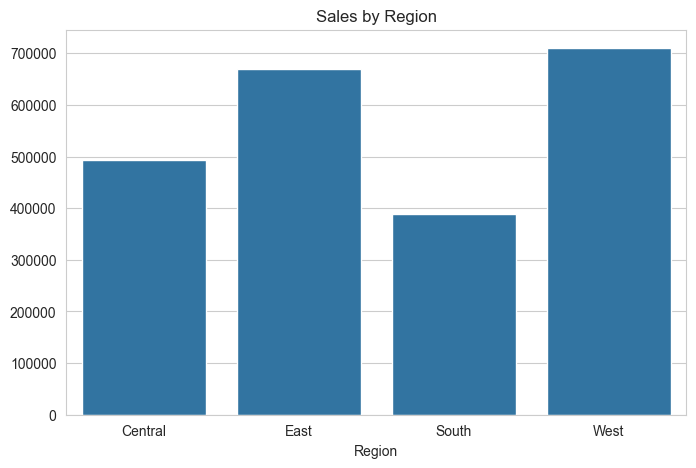

In [28]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Sales by Region")

plt.show()

# Segment Sales

In [29]:
segment_sales = df.groupby("Segment")["Sales"].sum()

segment_sales

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64

# Pie Chart

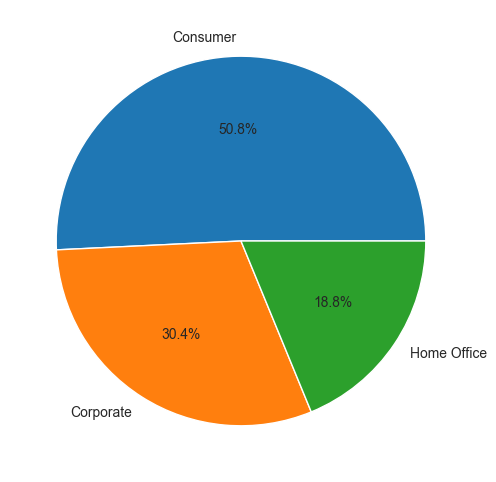

In [30]:
segment_sales.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.show()

# Sort Values

In [31]:
top_sub = df.groupby("Sub-Category")["Sales"].sum()

top_sub = top_sub.sort_values(ascending=False)

top_sub.head(10)

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Name: Sales, dtype: float64

# Top 10 Sub Category

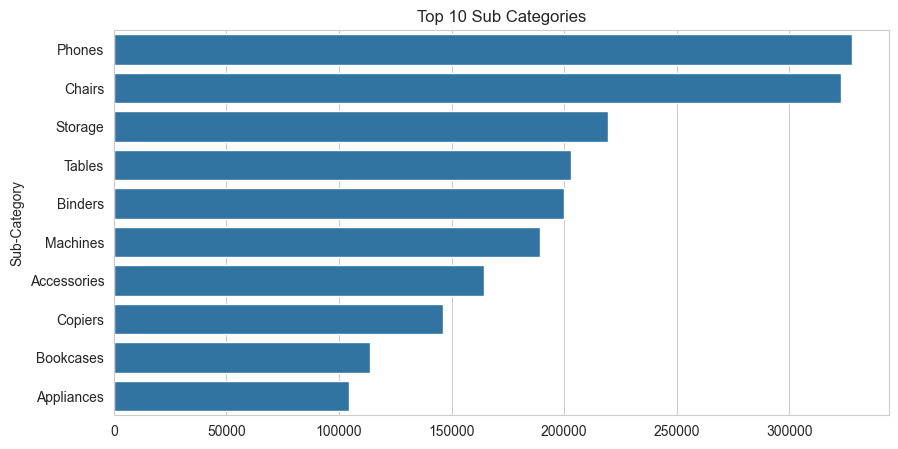

In [32]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_sub.head(10).values,
    y=top_sub.head(10).index
)

plt.title("Top 10 Sub Categories")

plt.show()

In [33]:
monthly_sales = df.groupby(
    pd.Grouper(
        key="Order Date",
        freq="ME"
    )
)["Sales"].sum().reset_index()

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


# Monthly Sales Plot

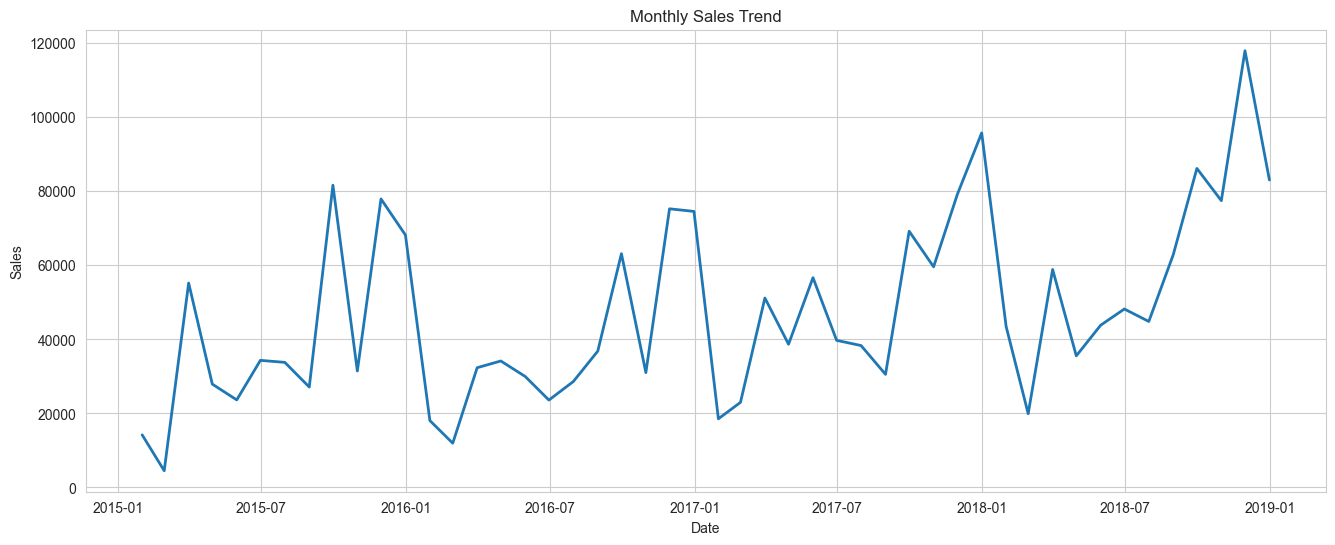

In [34]:
plt.figure(figsize=(16,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    linewidth=2
)

plt.title("Monthly Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

In [35]:
weekly_sales = df.groupby(
    pd.Grouper(
        key="Order Date",
        freq="W"
    )
)["Sales"].sum().reset_index()

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


# Weekly Sales Plot

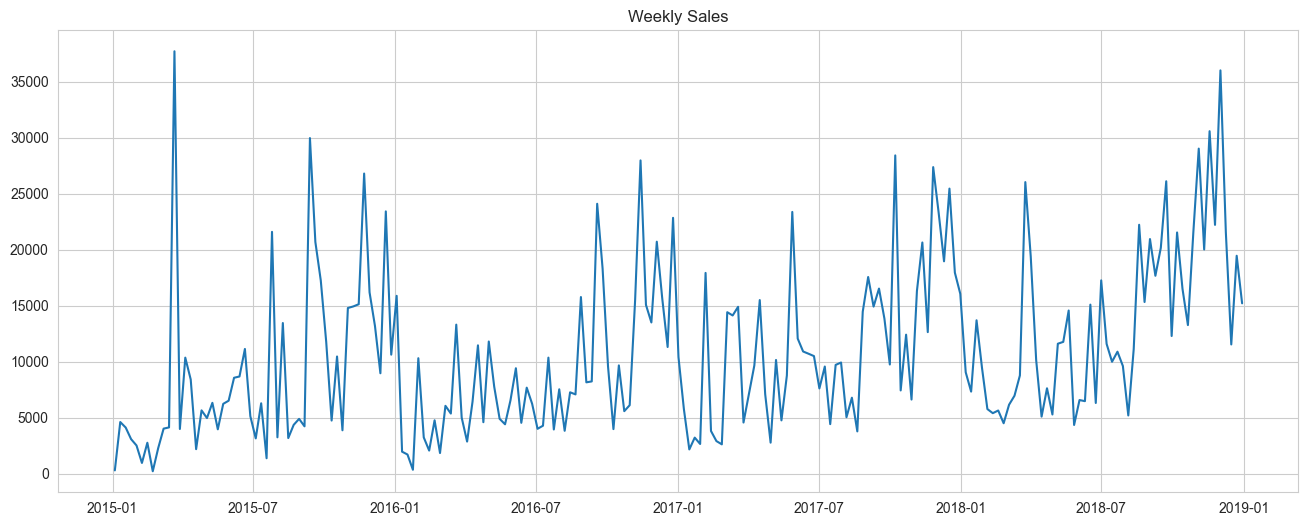

In [36]:
plt.figure(figsize=(16,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"]
)

plt.title("Weekly Sales")

plt.show()

# Category Sales

In [37]:
category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

In [38]:
region_year = df.groupby(
    ["Year","Region"]
)["Sales"].sum().reset_index()

region_year

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724
5,2016,East,153225.1830
6,2016,South,70076.0825
7,2016,West,133709.5675
8,2017,Central,145673.8800
9,2017,East,178511.5380


# Region Wise Sales Growth

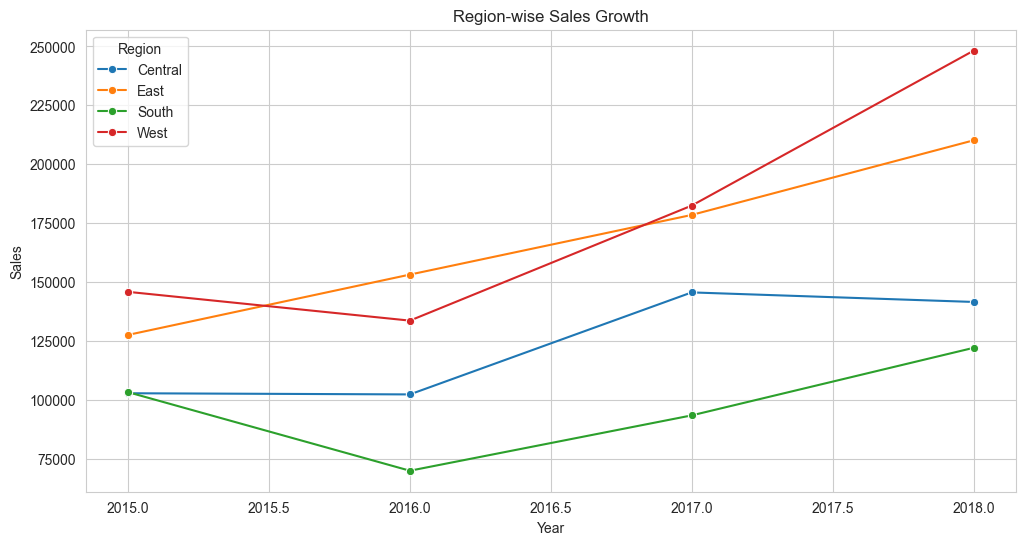

In [39]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=region_year,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Region-wise Sales Growth")

plt.show()

# Shipping

In [40]:
shipping = df.groupby("Region")["Shipping Days"].mean()

shipping

Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64

# Average Shipping Days

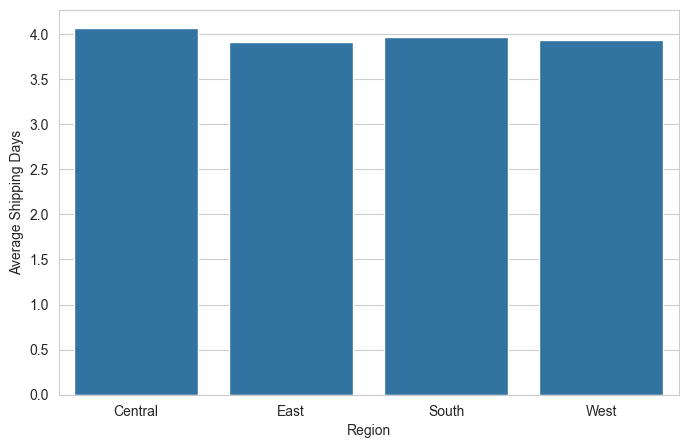

In [41]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=shipping.index,
    y=shipping.values
)

plt.ylabel("Average Shipping Days")

plt.show()

# Seasonality

In [42]:
seasonality = df.groupby("Month Name")["Sales"].sum()

seasonality = seasonality.reindex([
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
])

seasonality

Month Name
January       94291.6296
February      59371.1154
March        197573.5872
April        136283.0006
May          154086.7237
June         145837.5233
July         145535.6890
August       157315.9270
September    300103.4117
October      199496.2947
November     350161.7110
December     321480.1695
Name: Sales, dtype: float64

# Monthly Seasonality Plot

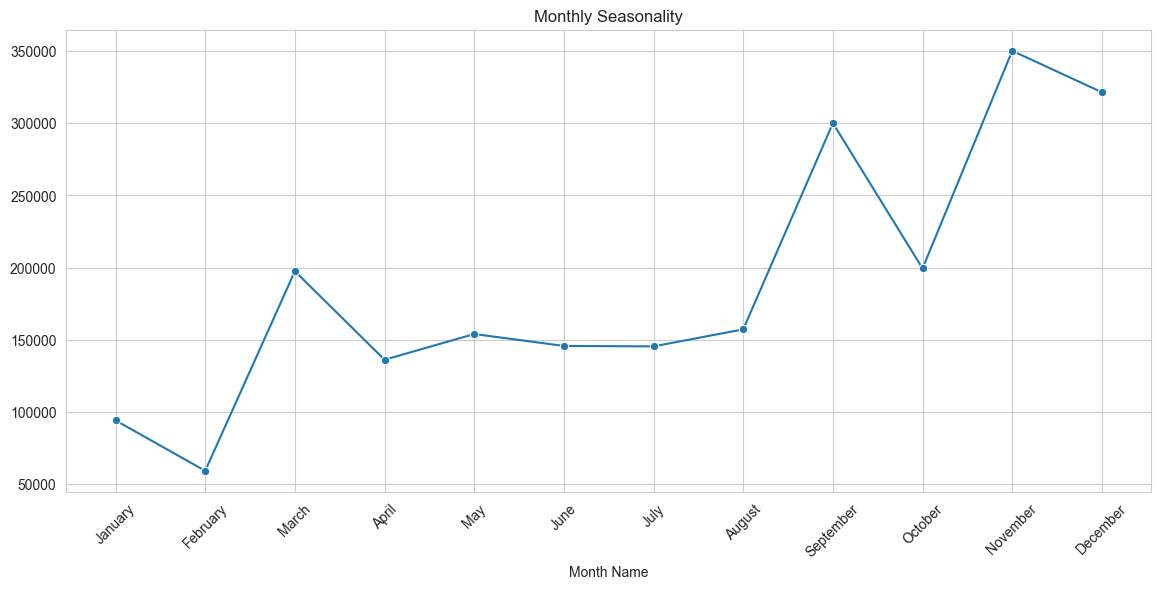

In [43]:
plt.figure(figsize=(14,6))

sns.lineplot(
    x=seasonality.index,
    y=seasonality.values,
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Seasonality")

plt.show()